In [1]:
%matplotlib ipympl

import mujoco

import time
import itertools
import numpy as np
import mediapy as media
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from pathlib import Path
import enum
from tqdm import tqdm

In [2]:
class Resolution(enum.Enum):
  SD = (480, 640)
  HD = (720, 1280)
  UHD = (2160, 3840)

res = Resolution.SD
h, w = res.value

In [3]:
# from robot_descriptions import spot_mj_description
model_dir = Path("mujoco_menagerie/boston_dynamics_spot/scene_arm.xml")
model_xml = model_dir / "scene_arm.xml"
# model = mujoco.MjModel.from_xml_path(spot_mj_description.MJCF_PATH)
model = mujoco.MjModel.from_xml_path(str(model_dir))
data = mujoco.MjData(model)

""

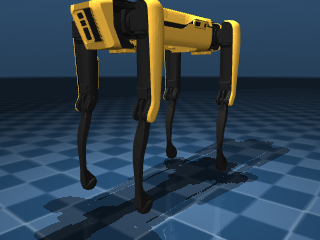

In [4]:
with mujoco.Renderer(model) as renderer:
  mujoco.mj_forward(model, data)
  renderer.update_scene(data)

  media.show_image(renderer.render())

""

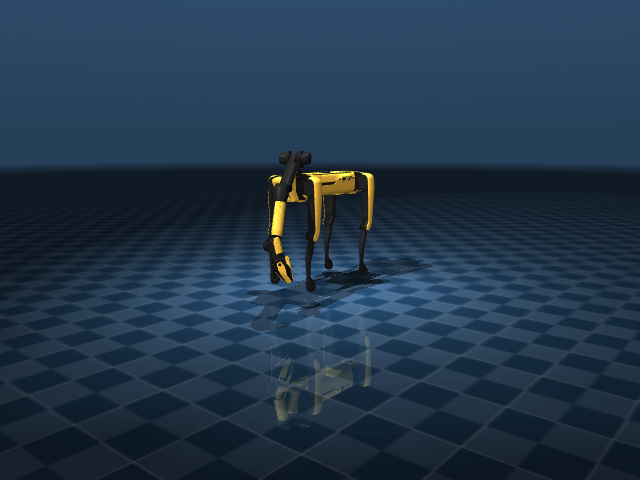

In [5]:
joints = ["arm_sh0", "arm_sh1", "arm_el0", "arm_el1", "arm_wr0", "arm_wr1"]
for joint in joints:
    data.joint(joint).qpos = np.pi/6

model.vis.global_.offheight = h
model.vis.global_.offwidth = w
camera = mujoco.MjvCamera()
mujoco.mjv_defaultFreeCamera(model, camera)
camera.distance = 4

renderer = mujoco.Renderer(model, height=h, width=w)

mujoco.mj_forward(model, data)
renderer.update_scene(data, camera)
media.show_image(renderer.render())

In [6]:
# print(data.joint('arm_sh0'))

joints = ["arm_sh0", "arm_sh1", "arm_el0", "arm_el1", "arm_wr0", "arm_wr1"]
bodies = ["arm_link_sh0", "arm_link_sh1", "arm_link_el0", "arm_link_el1", "arm_link_wr0", "arm_link_wr1"]
for body in bodies:
    print(np.round(data.body(body).xpos, 3))
print('\n')
for joint in joints:
    print(np.round(data.joint(joint).qpos, 3))

[0.292 0.    0.938]
[0.292 0.    0.938]
[0.546 0.147 0.769]
[0.777 0.28  0.457]
[0.777 0.28  0.457]
[0.777 0.28  0.457]


[0.524]
[0.524]
[0.524]
[0.524]
[0.524]
[0.524]


In [7]:
from dataclasses import dataclass
import numpy as np
import mediapy as media
from pathlib import Path
import enum
from tqdm import tqdm
import mujoco

from numpy import pi

def quartic(t: float) -> float:
  return 0 if abs(t) > 1 else (1 - t**2) ** 2


def blend_coef(t: float, duration: float, std: float) -> float:
  normalised_time = 2 * t / duration - 1
  return quartic(normalised_time / std)


In [8]:
res = Resolution.SD
fps = 30
duration = 5.0
ctrl_rate = 2
ctrl_std = 0.05

# Rendering options for visual and collision geoms.
vis = mujoco.MjvOption()
vis.geomgroup[2] = True
vis.geomgroup[3] = False
coll = mujoco.MjvOption()
coll.geomgroup[2] = False
coll.geomgroup[3] = True
coll.flags[mujoco.mjtVisFlag.mjVIS_CONVEXHULL] = True

# Sample actuator noise and smooth it.
nsteps = int(np.ceil(duration / model.opt.timestep))
perturb = np.random.randn(nsteps, model.nu)
width = int(nsteps * ctrl_rate / duration)
kernel = np.exp(-0.5 * np.linspace(-3, 3, width) ** 2)
kernel /= np.linalg.norm(kernel)
for i in range(model.nu):
  perturb[:, i] = np.convolve(perturb[:, i], kernel, mode="same")

# Set the desired control point.
if model.nkey > 0:
  mujoco.mj_resetDataKeyframe(model, data, 0)
  ctrl0 = data.ctrl.copy()
else:
  mujoco.mj_resetData(model, data)
  ctrl0 = np.mean(model.actuator_ctrlrange, axis=1)

camera.distance = 2

data.joint("arm_sh0").qpos = pi/4
data.ctrl[model.actuator("arm_sh0").id] = data.joint("arm_sh0").qpos
frames = []
for i in tqdm(range(nsteps)):
  # data.ctrl[0:12] = ctrl0[0:12] + ctrl_std * perturb[i, 0:12]
  mujoco.mj_step(model, data)
  if len(frames) < data.time * fps:
    renderer.update_scene(data, camera)
    frame = renderer.render().copy().astype(np.uint8)
    frames.append(frame)
media.show_video(frames, fps=fps, loop=False)

100%|██████████| 2500/2500 [00:01<00:00, 1253.76it/s]


This browser does not support the video tag.


Важно учитывать конфигурацию робота, в которой он находится в момент расчета координат (по результатам симуляции выше) или _(как-то)_ "сбросить" положение звеньев.

In [9]:
joints = ["arm_sh0", "arm_sh1", "arm_el0", "arm_el1", "arm_wr0", "arm_wr1"]
bodies = ["arm_link_sh0", "arm_link_sh1", "arm_link_el0", "arm_link_el1", "arm_link_wr0", "arm_link_wr1"]
for body in bodies:
    print(np.round(data.body(body).xpos, 3))
print('\n')
for joint in joints:
    print(np.round(data.joint(joint).qpos, 3))

[0.278 0.001 0.618]
[0.278 0.001 0.618]
[ 0.039 -0.239  0.62 ]
[0.321 0.043 0.716]
[0.321 0.043 0.716]
[0.321 0.043 0.716]


[0.785]
[-3.14]
[3.083]
[0.]
[0.003]
[-0.]


Да, длины звеньев в целом соответствуют значениям, приведенным производителем.

In [10]:
bodies = np.array(['arm_link_sh0',
                   'arm_link_sh1', 'arm_link_el0', 'arm_link_el1', 'arm_link_wr0', 'arm_link_wr1', 'arm_link_fngr'])

def calc_vel(x, y, z):
    if len(z) < 2:
        vel = np.array([0, 0, 0])
    else:
        vel = np.array([x[-1] - x[-2],
                        y[-1] - y[-2],
                        z[-1] - z[-2]])
    return vel

class DH_params():
    def __init__(self):
        self.a = np.zeros(6)
        self.d = np.zeros(6)
        self.alpha = np.zeros(6)
        self.theta = np.zeros(6)
    def add_theta(self, q):
        self.theta += q
    def dh_matrix(self, i):
        return np.array([
            [np.cos(self.theta[i]), -np.sin(self.theta[i])*np.cos(self.alpha[i]),np.sin(self.theta[i])*np.sin(self.alpha[i]),self.a[i]*np.cos(self.theta[i])],
            [np.sin(self.theta[i]), np.cos(self.theta[i])*np.cos(self.alpha[i]), -np.cos(self.theta[i])*np.sin(self.alpha[i]), self.a[i]*np.sin(self.theta[i])],
            [0, np.sin(self.alpha[i]), np.cos(self.alpha[i]), self.d[i]],
            [0, 0, 0, 1]])
       

l1 = 0.12
l2 = 0.339
l3 = 0.403
h3 = 0.075
l5 = 0.117

DH = DH_params()
DH.a = np.array([       0,      l2,     h3,     0,      0,      0])
DH.d = np.array([       l1,     0,      0,      l3,     0,      l5])
DH.alpha = np.array([   pi/2,   pi,     pi/2,   pi/2,   pi/2,   pi/2])
DH.theta = np.array([   0.0,    0.0,    0.0,    0.0,    0.0,    0.0])

DH.add_theta(np.array([0, -pi, pi, 0, 0, 0]))

def calc_Jacobian(DH_params, p_endeff):
    # p_endeff = data.body("arm_link_fngr").xpos - data.body("arm_link_sh0").xpos
    J = np.zeros((6, 6))
    T = np.eye(4)
    for i in range(6):
        A = DH_params.dh_matrix(i)
        T = T @ A
        z_i = T[0:3, 2]
        p_i = T[0:3, 3]
        J[0:3, i] = np.dot(z_i, (p_endeff - p_i))
        J[3:6, i] = z_i
        
    return J

  0%|          | 0/2500 [00:00<?, ?it/s]/tmp/ipykernel_26922/4117753697.py:22: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return np.array([
  3%|▎         | 63/2500 [00:00<00:07, 315.37it/s]

v_comp: [-0. -0. -0.]
qd: 0.0, qpos: [0.], +=qd: 0.0
qd: 0.0, qpos: [-2.35619449], +=qd: 0.0
qd: 0.0, qpos: [2.35619449], +=qd: 0.0
qd: 0.0, qpos: [0.], +=qd: 0.0
qd: 0.0, qpos: [0.], +=qd: 0.0
qd: 0.0, qpos: [0.], +=qd: 0.0


v_comp: [-146.   -0. -324.]
qd: 277.9894565545389, qpos: [0.55595467], +=qd: 0.5559789131090778
qd: -277.98945654395, qpos: [-2.91226662], +=qd: -0.5559789130878999
qd: -388.75103391215697, qpos: [1.57864975], +=qd: -0.777502067824314
qd: -316.51669396738606, qpos: [-0.63303831], +=qd: -0.6330333879347722
qd: -388.75103392175635, qpos: [-0.77749542], +=qd: -0.7775020678435127
qd: 239.46221912441777, qpos: [0.4789238], +=qd: 0.47892443824883557


v_comp: [-0.00464866 -0.00517115  0.02815185]
qd: 0.006030167937216412, qpos: [0.55581238], +=qd: 1.2060335874432823e-05
qd: -0.006030167937216429, qpos: [-2.91234871], +=qd: -1.2060335874432858e-05
qd: 0.015162981845663372, qpos: [1.57862459], +=qd: 3.0325963691326742e-05
qd: 0.0009696267356832625, qpos: [-0.63305647], +

  4%|▍         | 95/2500 [00:00<00:08, 295.53it/s]

v_comp: [ 0.09644642 -0.13201471  0.08829518]
qd: 0.01631248095678793, qpos: [0.57105564], +=qd: 3.262496191357586e-05
qd: -0.016312480956787882, qpos: [-2.940609], +=qd: -3.262496191357577e-05
qd: 0.043611989083092814, qpos: [1.60252333], +=qd: 8.722397816618562e-05
qd: 0.0028358422311405658, qpos: [-0.63125481], +=qd: 5.671684462281132e-06
qd: 0.04497040938058114, qpos: [-0.75399715], +=qd: 8.994081876116229e-05
qd: 0.033188502118310856, qpos: [0.49705332], +=qd: 6.637700423662172e-05


v_comp: [ 0.09894711 -0.13525567  0.08259102]
qd: 0.014315740751659055, qpos: [0.57116188], +=qd: 2.863148150331811e-05
qd: -0.014315740751659062, qpos: [-2.94096187], +=qd: -2.8631481503318124e-05
qd: 0.038281604972095956, qpos: [1.60251784], +=qd: 7.656320994419192e-05
qd: 0.0024894620800709234, qpos: [-0.63124199], +=qd: 4.978924160141847e-06
qd: 0.03947241714033803, qpos: [-0.75393292], +=qd: 7.894483428067606e-05
qd: 0.029128189715965522, qpos: [0.49711124], +=qd: 5.8256379431931044e-05


v_comp:

  7%|▋         | 168/2500 [00:00<00:06, 333.79it/s]

...

 95%|█████████▌| 2382/2500 [00:06<00:00, 438.67it/s]

v_comp: [-0.02331669 -0.03167737  0.00160547]
qd: -0.014783520602595376, qpos: [0.58158044], +=qd: -2.9567041205190752e-05
qd: 0.01478352060259534, qpos: [-2.95861226], +=qd: 2.956704120519068e-05
qd: -0.04415929228658462, qpos: [1.64439074], +=qd: -8.831858457316924e-05
qd: -0.002887881051166422, qpos: [-0.6288301], +=qd: -5.775762102332844e-06
qd: -0.044810496581542625, qpos: [-0.71101028], +=qd: -8.962099316308525e-05
qd: -0.03102771494026644, qpos: [0.52812489], +=qd: -6.205542988053288e-05


v_comp: [-0.0231471  -0.03153195  0.00136699]
qd: -0.014765701324769207, qpos: [0.5815685], +=qd: -2.9531402649538415e-05
qd: 0.01476570132476922, qpos: [-2.95859327], +=qd: 2.953140264953844e-05
qd: -0.04409600148798773, qpos: [1.64429622], +=qd: -8.819200297597546e-05
qd: -0.002883784378088534, qpos: [-0.62883438], +=qd: -5.767568756177068e-06
qd: -0.04474752651762837, qpos: [-0.71109975], +=qd: -8.949505303525675e-05
qd: -0.0309883916664074, qpos: [0.52806275], +=qd: -6.19767833328148e-05



100%|██████████| 2500/2500 [00:06<00:00, 397.41it/s]

qd: -0.018582059011898303, qpos: [0.57964686], +=qd: -3.7164118023796606e-05
qd: 0.0185820590118983, qpos: [-2.95648847], +=qd: 3.71641180237966e-05
qd: -0.054280210929537075, qpos: [1.63517655], +=qd: -0.00010856042185907415
qd: -0.003554194110864415, qpos: [-0.6293072], +=qd: -7.10838822172883e-06
qd: -0.05523728055402628, qpos: [-0.7198151], +=qd: -0.00011047456110805257
qd: -0.038762859102769956, qpos: [0.52199612], +=qd: -7.752571820553991e-05


v_comp: [-0.00395467 -0.04090905 -0.02087492]
qd: -0.01861955305479302, qpos: [0.57960743], +=qd: -3.723910610958604e-05
qd: 0.01861955305479302, qpos: [-2.95645466], +=qd: 3.723910610958604e-05
qd: -0.054374399298352215, qpos: [1.63506321], +=qd: -0.00010874879859670443
qd: -0.0035604158968748573, qpos: [-0.62931444], +=qd: -7.120831793749715e-06
qd: -0.05533519024622009, qpos: [-0.71992667], +=qd: -0.00011067038049244019
qd: -0.038838063522087005, qpos: [0.52191848], +=qd: -7.767612704417402e-05


v_comp: [-0.00377292 -0.04108792 -0.0209

This browser does not support the video tag.


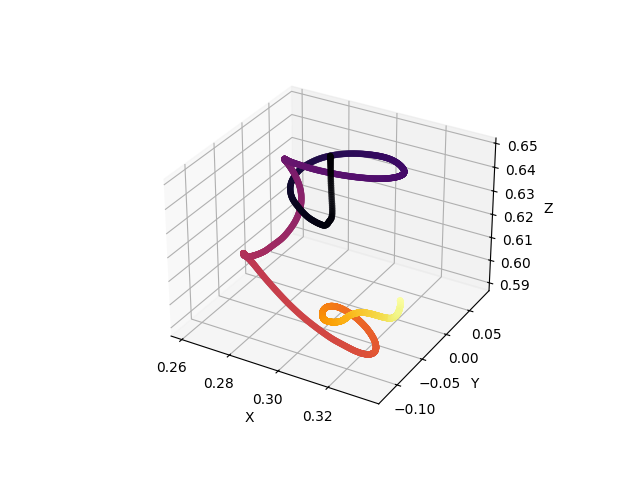

In [18]:
duration = 5.0
ctrl_rate = 2
ctrl_std = 0.075

np.random.seed(10)

# Sample actuator noise and smooth it.
nsteps = int(np.ceil(duration / model.opt.timestep))
perturb = np.random.randn(nsteps, model.nu)
width = int(nsteps * ctrl_rate / duration)
kernel = np.exp(-0.5 * np.linspace(-3, 3, width) ** 2)
kernel /= np.linalg.norm(kernel)
for i in range(model.nu):
  perturb[:, i] = np.convolve(perturb[:, i], kernel, mode="same")

# Set the desired control point.
if model.nkey > 0:
  mujoco.mj_resetDataKeyframe(model, data, 0)
  ctrl0 = data.ctrl.copy()
else:
  mujoco.mj_resetData(model, data)
  ctrl0 = np.mean(model.actuator_ctrlrange, axis=1)

t = np.array([])
x, y, z = np.array([]), np.array([]), np.array([])
xe, ye, ze = np.array([]), np.array([]), np.array([])
xvel, yvel, zvel = np.array([]), np.array([]), np.array([])

frames = []

joints = ["arm_sh0", "arm_sh1", "arm_el0", "arm_el1", "arm_wr0", "arm_wr1"]
data.joint("arm_sh0").qpos = 0.0
data.joint("arm_sh1").qpos = -3*pi/4
data.joint("arm_el0").qpos = 3*pi/4
for joint_name in joints:
    data.ctrl[model.actuator(joint_name).id] = data.joint(joint_name).qpos

p_base_last = data.body("arm_link_sh0").xpos.copy() 
p_endeff_last = data.body("arm_link_fngr").xpos - p_base_last
kp = 0.1


p_desired = data.body("arm_link_fngr").xpos - data.body("arm_link_sh0").xpos

for i in tqdm(range(nsteps)):
  data.ctrl[0:12] = ctrl0[0:12] + ctrl_std * perturb[i, 0:12]
  
  p_base = data.body("arm_link_sh0").xpos.copy()
  p_endeff = data.body("arm_link_fngr").xpos - p_base
  
  dt = model.opt.timestep
  v_comp = - (p_base - p_base_last) / dt
  print(f'v_comp: {v_comp}')
  # print(p_base, p_base_last)
  # print(v_comp)
  
  # v_comp = - data.body("arm_link_sh0").cvel
  
  v_corr = (p_desired - p_endeff) 
  v_endeff_linear = (p_endeff - p_endeff_last)
  v_command = v_comp + v_corr

  v_angular = np.zeros(3)
  v_endeff = np.concatenate([v_endeff_linear, v_angular])
  J = calc_Jacobian(DH, p_endeff)
  try:
    J_inv = np.linalg.pinv(J)
    # Желаемая скорость - стабилизация к начальной точке
    # desired_vel = -kp * p_endeff  # Пропорциональный регулятор
    qdot = J_inv @ np.concatenate([v_comp, np.zeros(3)])
    for joint, qd in zip(joints, qdot):
      data.joint(joint).qpos += qd * dt
      data.ctrl[model.actuator(joint).id] += qd * dt
      print(f'qd: {qd}, qpos: {data.joint(joint).qpos}, +=qd: {qd * dt}')
    print('\n')
    # print(qdot)
    # data.ctrl[12:18] += qdot * dt
  except np.linalg.LinAlgError:
    print("Singular matrix encountered")

  if (data.body("arm_link_sh0").xpos[0] != 0 and data.body("arm_link_fngr").xpos[0] != 0):
    t = np.append(t, i)
    x = np.append(x, data.body("arm_link_sh0").xpos[0])
    y = np.append(y, data.body("arm_link_sh0").xpos[1])
    z = np.append(z, data.body("arm_link_sh0").xpos[2])
    xe = np.append(x, data.body("arm_link_fngr").xpos[0])
    ye = np.append(y, data.body("arm_link_fngr").xpos[1])
    ze = np.append(z, data.body("arm_link_fngr").xpos[2])
    vel = calc_vel(x, y, z)
    vel *= 10^5
    xvel =np.append(xvel, vel[0])
    yvel =np.append(yvel, vel[1])
    zvel =np.append(zvel, vel[2])
  # xvel = np.append(xvel, data.body("arm_link_sh0").cvel[0])
  # yvel = np.append(yvel, data.body("arm_link_sh0").cvel[1])
  # zvel = np.append(zvel, data.body("arm_link_sh0").cvel[2])
  
  mujoco.mj_step(model, data)
  
  p_base_last = p_base.copy()
  
  p_endeff_last = p_endeff.copy()
  
  DH.theta = np.array([data.joint("arm_sh0").qpos, data.joint("arm_sh1").qpos, data.joint("arm_el0").qpos,
                       data.joint("arm_el1").qpos, data.joint("arm_wr0").qpos, data.joint("arm_wr1").qpos])
  
  if len(frames) < data.time * fps:
    renderer.update_scene(data, camera)
    frame = renderer.render().copy().astype(np.uint8)
    frames.append(frame)

media.show_video(frames, fps=fps, loop=False)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z, c=np.linspace(0, 1, len(x)), cmap='inferno', linewidth=0.2)
# ax.scatter(xe, ye, ze, c=np.linspace(0, 1, len(xe)), cmap='cool', linewidth=0.2)
for i in range(0, len(t), 100):
  ax.quiver(x[i], y[i], z[i], xvel[i], yvel[i], zvel[i], color='r', linewidth=1)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()
# 
#     Как показала практика - скорость в модели не соответствует реальному
#   направлению двжиения базы. Лучше использовать изменения координат с малым шагом.
# 